In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from sklearn.manifold import TSNE

In [3]:
palette_set2 = sns.color_palette("Set2")
color_1 = palette_set2[0]  
color_2 = palette_set2[1]  

# Best MiniBatch Size search

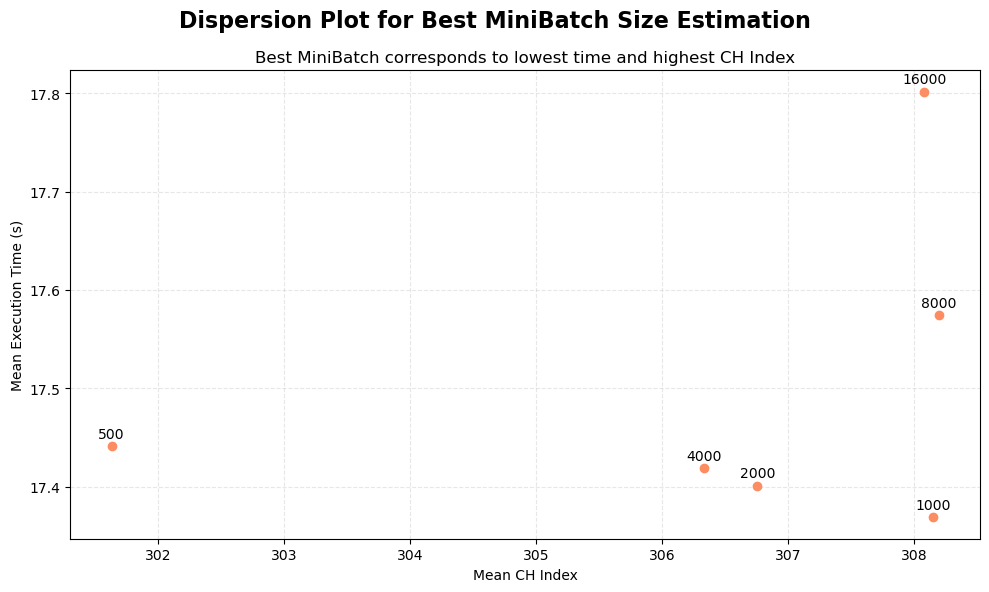

In [23]:
b_data = pd.read_csv("runs/stats_b_search.csv")
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(b_data['mean_ch'], b_data['mean_time'], color= color_2)

for idx, row in b_data.iterrows():
    # Estraiamo il valore di bsize (presumo sia un intero, quindi lo converto per sicurezza)
    bsize = int(row['batch_size'])
    
    ax.annotate(
        f"{bsize}",                 
        (row['mean_ch'], row['mean_time']), 
        textcoords="offset points",        
        xytext=(0, 6),                     
        ha='center',                       
        fontsize=10,                       
        color='black'                      
    )

fig.suptitle('Dispersion Plot for Best MiniBatch Size Estimation', fontsize=16, fontweight='bold')
ax.set_title('Best MiniBatch corresponds to lowest time and highest CH Index')
ax.set_xlabel('Mean CH Index')
ax.set_ylabel('Mean Execution Time (s)')

plt.grid(linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Spark Session Topologies Benchmark

In [23]:
#Data import
spark_session = ['thin', 'balanced', 'fat']
aesthetic = ['Thin', 'Balanced', 'Fat']
topology = []
for i, top in enumerate(spark_session):
    data = pd.read_csv(f"runs/{top}_topology.csv")
    data['Topology'] = aesthetic[i]
    topology.append(data)
    
df_topology = pd.concat(topology, ignore_index=True)

## Boxplot

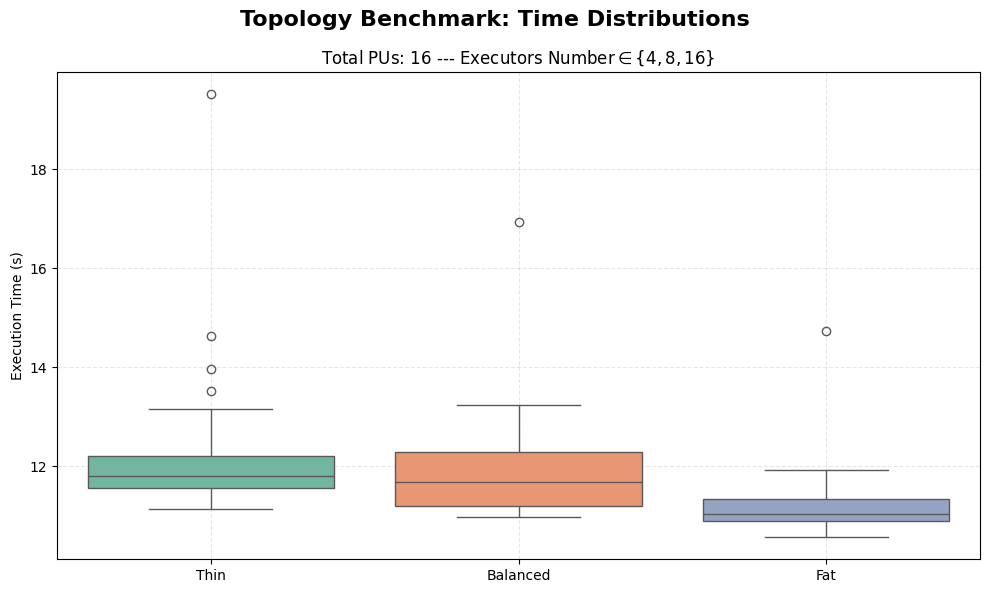

In [24]:
fig, ax = plt.subplots(figsize=(10,6))
sns.boxplot(x='Topology', y='execution_time', hue= 'Topology', legend=False, data= df_topology, palette='Set2')
fig.suptitle('Topology Benchmark: Time Distributions', fontsize=16, fontweight='bold')
ax.set_title(r'Total PUs: 16 --- Executors Number$\in \{4,8,16\}$')
ax.set_xlabel('')
ax.set_ylabel('Execution Time (s)')

plt.grid(linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## Line Plot

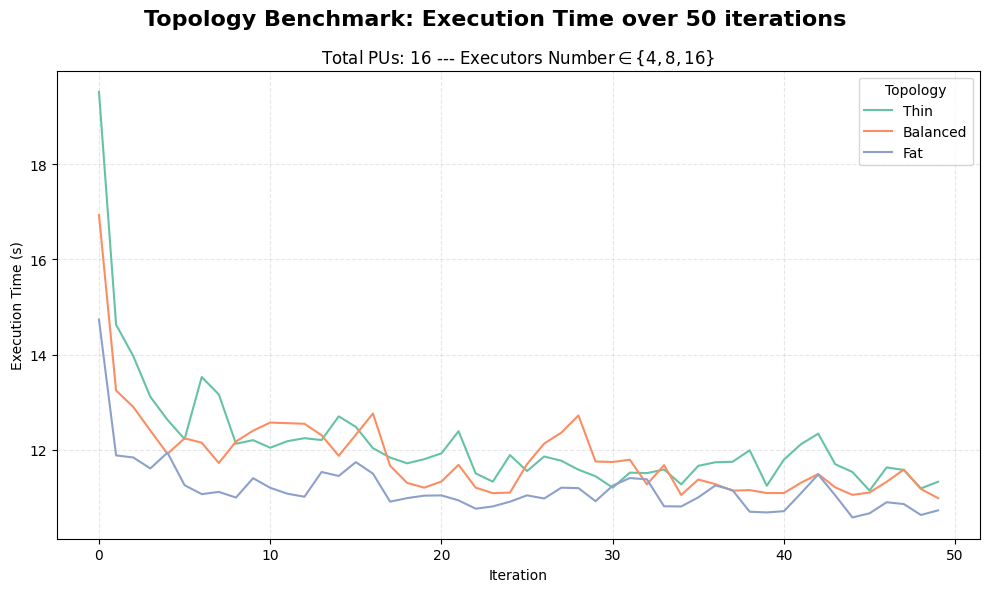

In [25]:
fig, ax = plt.subplots(figsize=(10,6))
sns.lineplot(x='iteration_id', y='execution_time', hue='Topology', data=df_topology, legend=True, palette='Set2')
fig.suptitle('Topology Benchmark: Execution Time over 50 iterations', fontsize=16, fontweight='bold')
ax.set_title(r'Total PUs: 16 --- Executors Number$\in \{4,8,16\}$')
ax.set_xlabel('Iteration')
ax.set_ylabel('Execution Time (s)')
plt.grid(linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## Barplot

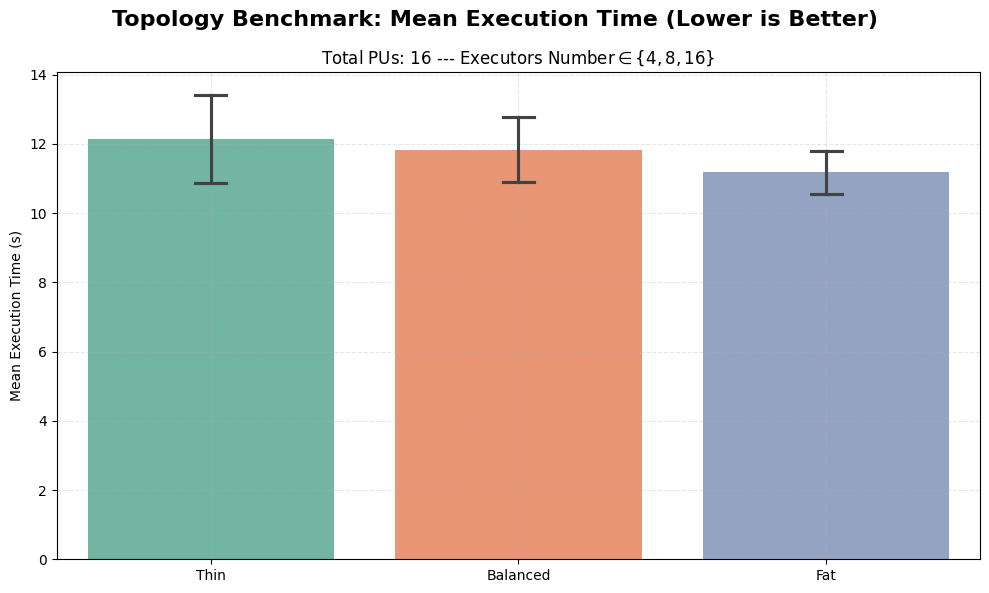

In [26]:
fig, ax = plt.subplots(figsize=(10,6))
sns.barplot(x='Topology', y='execution_time', hue='Topology', legend=False, data=df_topology, palette='Set2', errorbar='sd', capsize=0.1)
fig.suptitle('Topology Benchmark: Mean Execution Time (Lower is Better)', fontsize=16, fontweight='bold')
ax.set_title(r'Total PUs: 16 --- Executors Number$\in \{4,8,16\}$')
ax.set_xlabel('')
ax.set_ylabel('Mean Execution Time (s)')
plt.grid(linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Partitions Benchmark

In [27]:
partitions = [4,8,16,32,48,64,80,96]
parts = []
stats = []
for num in partitions:
    part = pd.read_csv(f"runs/partitions{num}.csv")
    part['Partitions'] = num
    parts.append(part)

for num in partitions:
    stat = pd.read_csv(f"runs/stats_partitions{num}.csv")
    stat['Partitions'] = num
    stats.append(stat)

df_parts = pd.concat(parts, ignore_index=True)
df_strong = pd.concat(stats, ignore_index=True)

df_fluct = df_parts[df_parts['Partitions'] > 32]

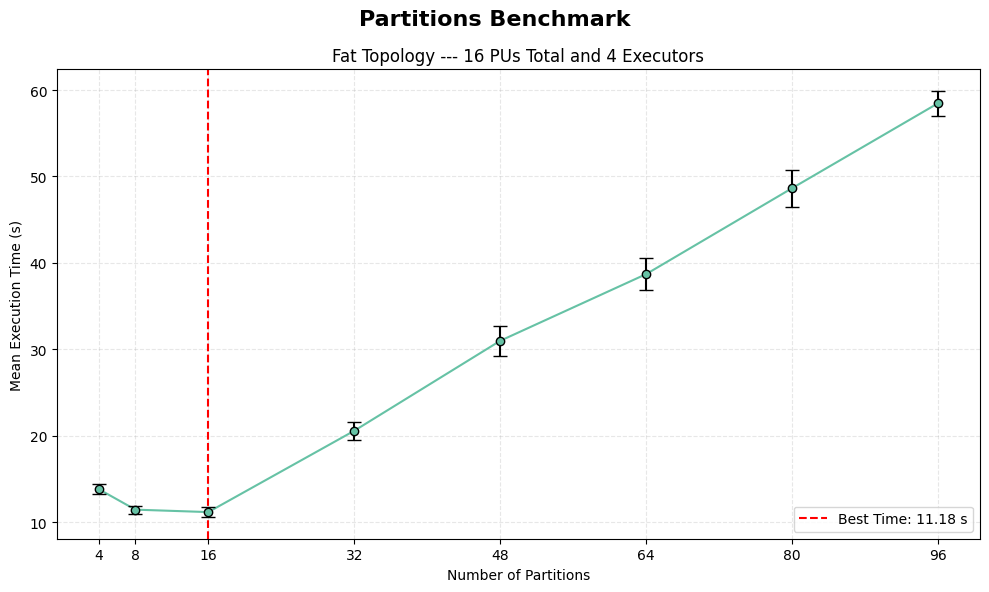

In [28]:

fig, ax = plt.subplots(figsize=(10,6))
sns.lineplot(data=df_strong, x='Partitions', y='mean_time', marker='o', color=color_1)

indice_min = df_strong['mean_time'].idxmin()
min_time = df_strong.loc[indice_min, 'mean_time']
best_parts = df_strong.loc[indice_min, 'Partitions']

label = f'Best Time: {min_time:.2f} s'
ax.axvline(best_parts, linestyle = '--', color='red', label = label)


ax.errorbar(
    x=df_strong['Partitions'], 
    y=df_strong['mean_time'], 
    yerr=df_strong['std_time'], 
    fmt='o',  
    markerfacecolor=color_1 ,                  
    c='black', 
    capsize=5, 
    elinewidth=1.5
)
fig.suptitle('Partitions Benchmark', fontsize=16, fontweight='bold')
ax.set_title('Fat Topology --- 16 PUs Total and 4 Executors')
ax.set_xlabel('Number of Partitions')
ax.set_ylabel('Mean Execution Time (s)')
ax.set_xticks(df_strong['Partitions'])
plt.legend()
plt.grid(linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

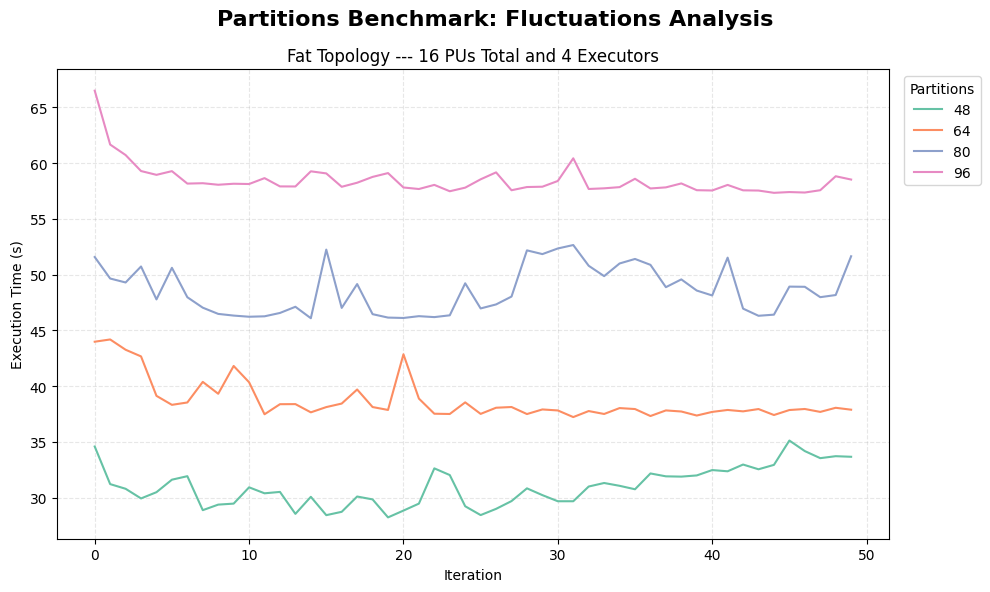

In [29]:
fig, ax = plt.subplots(figsize=(10,6))
sns.lineplot(x='iteration_id', y='execution_time', hue='Partitions', data=df_fluct, legend=True, palette='Set2')
fig.suptitle('Partitions Benchmark: Fluctuations Analysis', fontsize=16, fontweight='bold')
ax.set_title('Fat Topology --- 16 PUs Total and 4 Executors')
ax.set_xlabel('Iteration')
ax.set_ylabel('Execution Time (s)')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', title='Partitions')
plt.grid(linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Strong Scaling

In [30]:
#Data import
cores = ['4c', '8c', '12c', '16c']
executors = ['1', '2', '3', '4']
raws = []
stats = []

for i, core in enumerate(cores):
    data = pd.read_csv(f"runs/strong_{core}.csv")
    data['executors'] = executors[i]
    raws.append(data)

for i, core in enumerate(cores):
    data = pd.read_csv(f"runs/stats_strong_{core}.csv")
    data['executors'] = executors[i]
    stats.append(data)


df_raws = pd.concat(raws, ignore_index=True)
df_strong = pd.concat(stats, ignore_index=True)

## Barplot

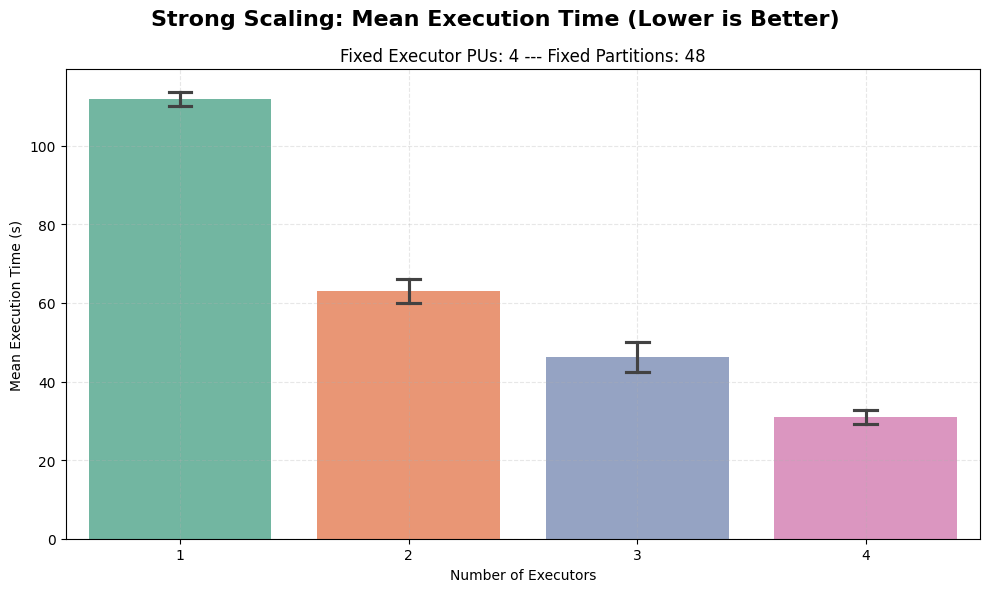

In [31]:
fig, ax = plt.subplots(figsize=(10,6))
ax = sns.barplot(x='executors', y='execution_time', hue='executors', legend=False, data=df_raws, palette='Set2', errorbar='sd', capsize=0.1)

fig.suptitle('Strong Scaling: Mean Execution Time (Lower is Better)', fontsize=16, fontweight='bold')
ax.set_title(r'Fixed Executor PUs: 4 --- Fixed Partitions: 48')
ax.set_xlabel('Number of Executors')
ax.set_ylabel('Mean Execution Time (s)')
plt.grid(linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## Speed Up

/tmp/ipykernel_642353/485414475.py:16: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x='executors', y='ideal_speedup', data=df_strong, palette='Set2', linestyle = '--', label ='Ideal Speed Up', color=color_1)
/tmp/ipykernel_642353/485414475.py:17: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x='executors', y='real_speedup', data=df_strong, palette='Set2', marker = 'o',label = 'Real Speed Up', color=color_2)


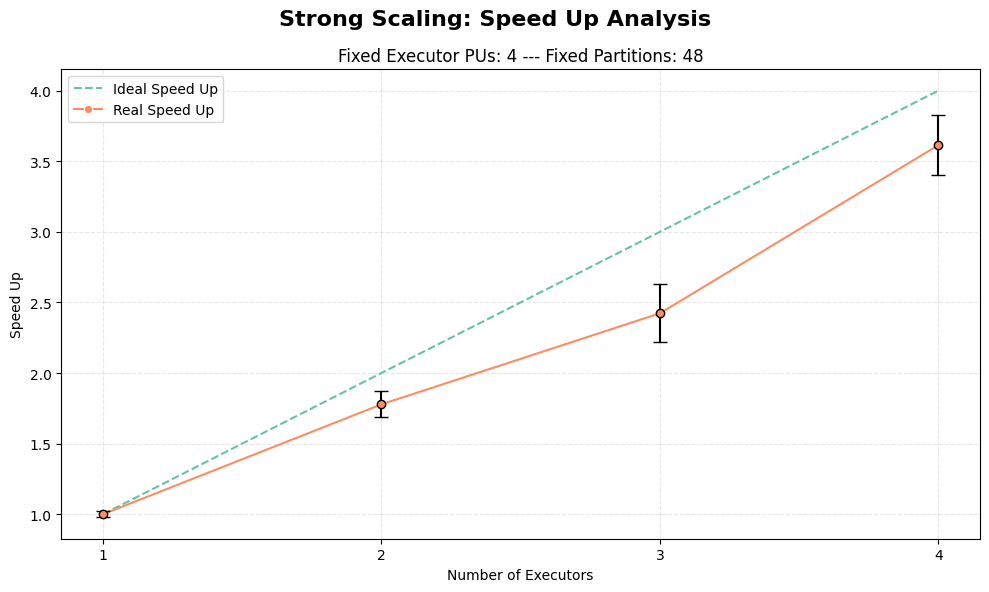

In [32]:
base_time = df_strong['mean_time'].iloc[0]
base_error = df_strong['std_time'].iloc[0]

df_strong['ideal_speedup'] = [1,2,3,4]
df_strong['real_speedup'] = base_time / df_strong['mean_time']


rel_error_base = base_error / base_time
rel_error_current = df_strong['std_time'] / df_strong['mean_time']
df_strong['speedup_error'] = df_strong['real_speedup'] * np.sqrt(rel_error_base**2 + rel_error_current**2)

df_strong['efficiency'] = (df_strong['real_speedup']/df_strong['ideal_speedup']) * 100
df_strong['efficiency_std'] = (df_strong['speedup_error']/df_strong['ideal_speedup']) * 100

fig, ax = plt.subplots(figsize=(10,6))
sns.lineplot(x='executors', y='ideal_speedup', data=df_strong, palette='Set2', linestyle = '--', label ='Ideal Speed Up', color=color_1)
sns.lineplot(x='executors', y='real_speedup', data=df_strong, palette='Set2', marker = 'o',label = 'Real Speed Up', color=color_2)

ax.errorbar(
    x=df_strong['executors'], 
    y=df_strong['real_speedup'], 
    yerr=df_strong['speedup_error'], 
    fmt='o', 
    markerfacecolor=color_2 ,                  
    c='black', 
    capsize=5, 
    elinewidth=1.5
)

fig.suptitle('Strong Scaling: Speed Up Analysis', fontsize=16, fontweight='bold')
ax.set_title(r'Fixed Executor PUs: 4 --- Fixed Partitions: 48')
ax.set_xlabel('Number of Executors')
ax.set_ylabel('Speed Up')
plt.grid(linestyle ='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Weak Scaling

In [33]:
#Data import
cores = ['4c', '8c', '12c', '16c']
executors = ['1', '2', '3', '4']
stats = []

for i, core in enumerate(cores):
    data = pd.read_csv(f"runs/stats_weak_{core}.csv")
    data['executors'] = executors[i]
    stats.append(data)

df_stats = pd.concat(stats, ignore_index=True)

/tmp/ipykernel_642353/1194783325.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x='executors', y='mean_time', data=df_stats, palette='Set2', marker = 'o', color=color_1)


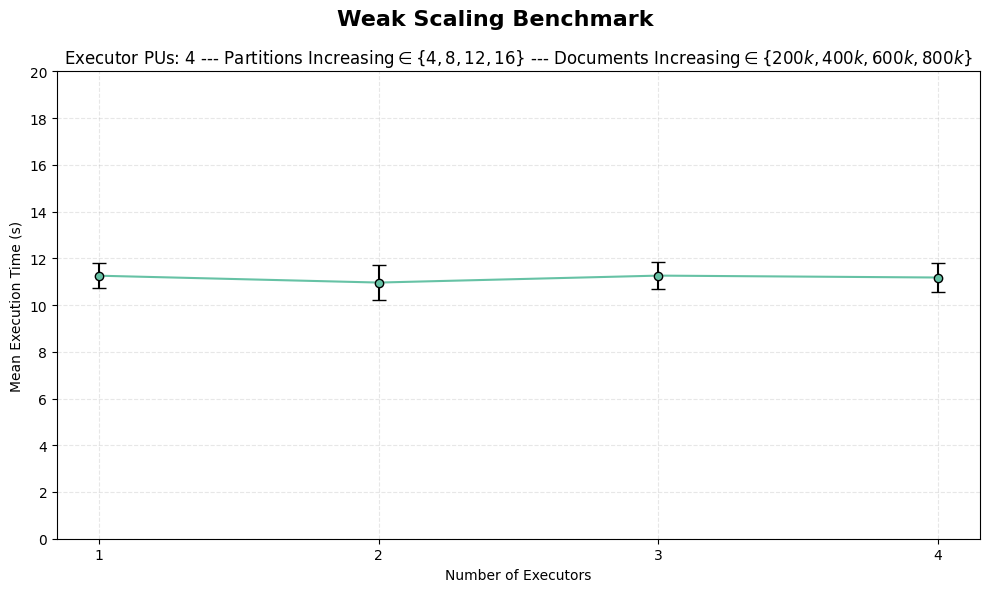

In [34]:
fig, ax = plt.subplots(figsize=(10,6))
sns.lineplot(x='executors', y='mean_time', data=df_stats, palette='Set2', marker = 'o', color=color_1)

ax.errorbar(
    x=df_stats['executors'], 
    y=df_stats['mean_time'], 
    yerr=df_stats['std_time'], 
    fmt='o', 
    markerfacecolor=color_1 ,                  
    c='black', 
    capsize=5, 
    elinewidth=1.5
)
fig.suptitle('Weak Scaling Benchmark', fontsize=16, fontweight='bold')
ax.set_title(r'Executor PUs: 4 --- Partitions Increasing$\in\{4,8,12,16\}$ --- Documents Increasing$\in \{200k,400k,600k,800k\}$')
ax.set_xlabel('Number of Executors')
ax.set_ylabel('Mean Execution Time (s)')
ax.set_ylim([0,20])
ax.set_yticks(np.arange(0,22,2))
plt.grid(linestyle ='--', alpha=0.3)
plt.tight_layout()
plt.show()

# MiniBatch K-Means V.S. Classic K-Means 

In [35]:
#Data import
cores = ['4c', '8c', '12c', '16c']
executors = ['1', '2', '3', '4']
kmeans = []

for i, core in enumerate(cores):
    data = pd.read_csv(f"runs/stats_k_means_{core}.csv")
    data['executors'] = executors[i]
    data['Clustering Method'] = 'Classic K-Means'
    kmeans.append(data)

df_k_means = pd.concat(kmeans, ignore_index=True)

df_strong['Clustering Method'] = 'MiniBatch'

df_comparison = pd.concat([df_strong, df_k_means], ignore_index = True)


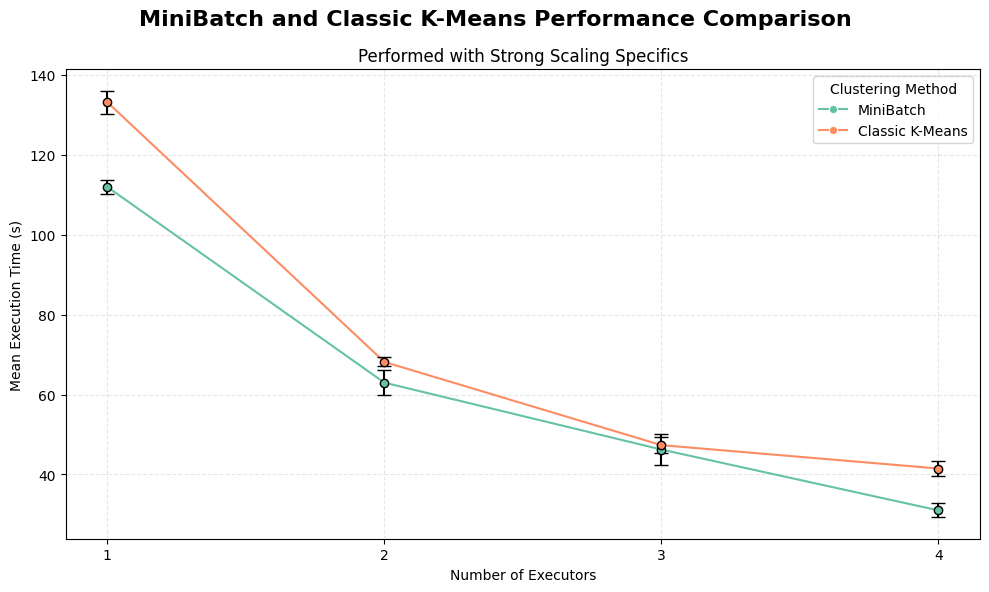

In [36]:
fig, ax = plt.subplots(figsize=(10,6))
sns.lineplot(x='executors', y='mean_time', data=df_comparison, hue = 'Clustering Method', palette='Set2', marker = 'o')

clustering = df_comparison['Clustering Method'].unique()
colors = [color_1, color_2]
for i, cat in enumerate(clustering):
    df_filtered = df_comparison[df_comparison['Clustering Method'] == cat]
    
    ax.errorbar(
    x=df_filtered['executors'], 
    y=df_filtered['mean_time'], 
    yerr=df_filtered['std_time'], 
    fmt='o', 
    markerfacecolor= colors[i] ,                  
    c='black', 
    capsize=5, 
    elinewidth=1.5
)


fig.suptitle('MiniBatch and Classic K-Means Performance Comparison', fontsize=16, fontweight='bold')
ax.set_title(r'Performed with Strong Scaling Specifics')
ax.set_xlabel('Number of Executors')
ax.set_ylabel('Mean Execution Time (s)')
plt.grid(linestyle ='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Clustering Population 

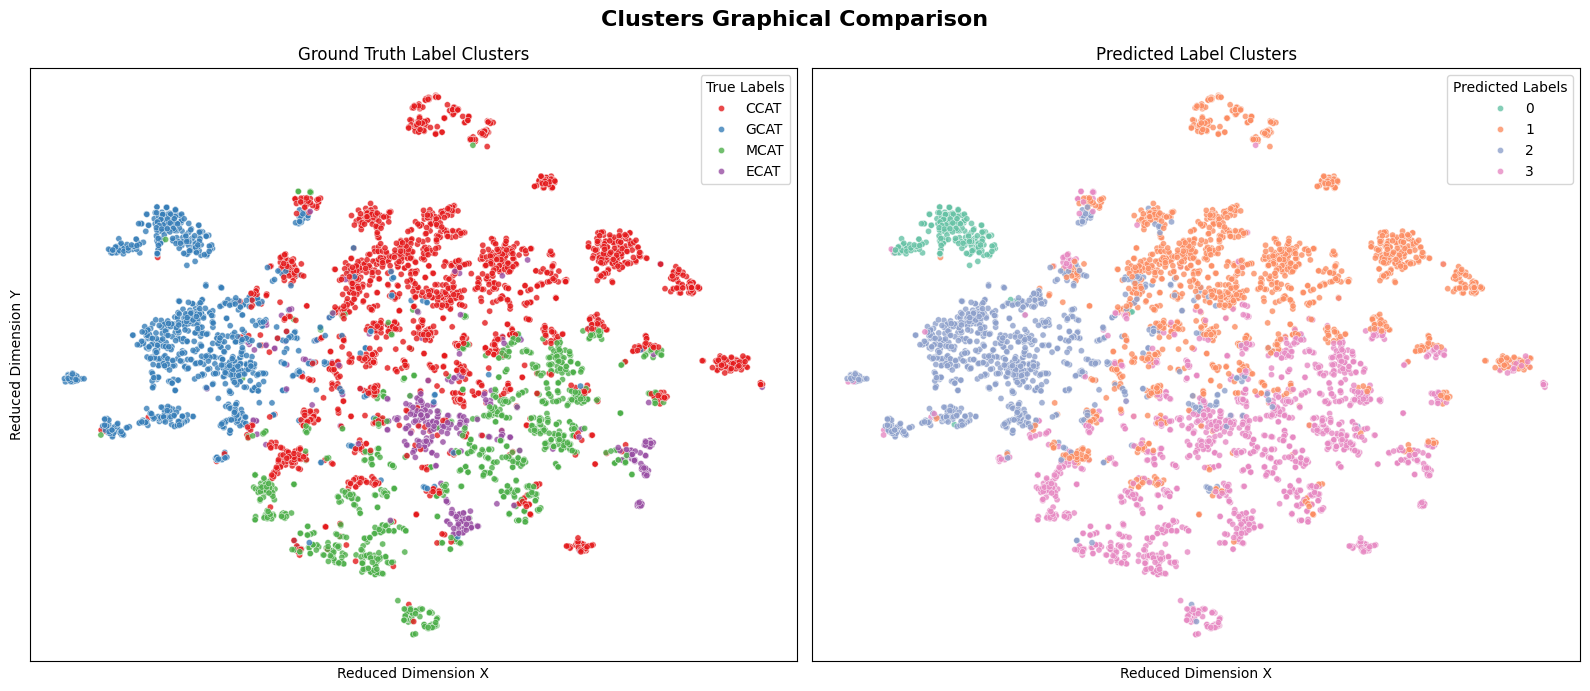

In [37]:
df = pd.read_csv("runs/minibatch_plot.csv")

# ast.literal_eval reads features "[-0.2, 0.3]" and translates it to python list
df['features'] = df['features'].apply(ast.literal_eval)

X = np.stack(df['features'].values)

# Dimension reduction with t-SNE from 100 --> 2 dimensions
tsne = TSNE(n_components=2, random_state=42, learning_rate='auto')
X_2d = tsne.fit_transform(X)

df['Reduced Dimension X'] = X_2d[:, 0]
df['Reduced Dimension Y'] = X_2d[:, 1]

df = df.rename(columns={
    'true_labels': 'True Labels', 
    'predicted_labels': 'Predicted Labels'
})

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

# Ground truth plot on the left
sns.scatterplot(
    data=df, x='Reduced Dimension X', y='Reduced Dimension Y', 
    hue='True Labels', palette='Set1', 
    ax=axes[0], s=20, alpha=0.8
)
axes[0].set_title('Ground Truth Label Clusters')
axes[0].set_xticks([])
axes[0].set_yticks([])

# predicted labels on the right
sns.scatterplot(
    data=df, x='Reduced Dimension X', y='Reduced Dimension Y', 
    hue='Predicted Labels', palette='Set2', 
    ax=axes[1], s=20, alpha=0.8
)
axes[1].set_title('Predicted Label Clusters')
axes[1].set_xticks([])
axes[1].set_yticks([])

plt.suptitle('Clusters Graphical Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

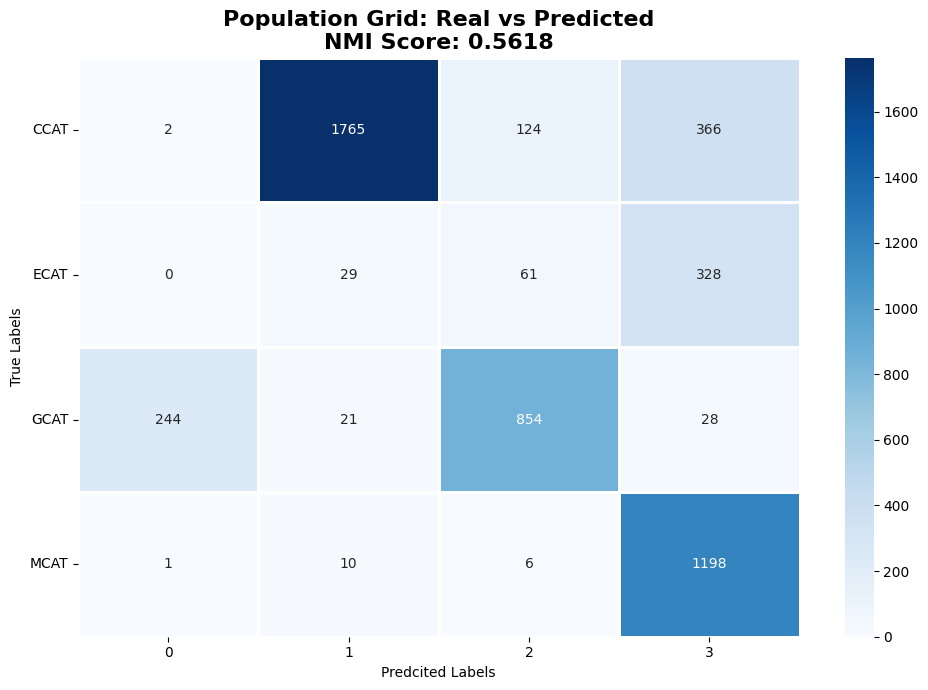

In [38]:
# Creates grid for heatmap
tabella_incrociata = pd.crosstab(
    index=df['True Labels'], 
    columns=df['Predicted Labels'],
    rownames=['True Labels'], 
    colnames=['Predcited Labels']
)

plt.figure(figsize=(10, 7))

# annot shows numbers inside squares and fmt='d' shows them as int()
sns.heatmap(tabella_incrociata, annot=True, fmt='d', cmap='Blues', linewidths=1, linecolor='white')

# Show NMI score obtained
nmi_score = df['NMI_score'].iloc[0]

plt.title(f'Population Grid: Real vs Predicted\nNMI Score: {nmi_score:.4f}', fontsize=16, fontweight='bold')
plt.yticks(rotation=0) # horizontal vertical ticks labels

plt.tight_layout()
plt.show()